In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


In [3]:
import kagglehub

# Downloads to a local cache the first time you run it
path = kagglehub.dataset_download("arjunbhasin2013/ccdata")
print("Dataset downloaded to:", path)

df = pd.read_csv(f"{path}/CC GENERAL.csv")
df.shape


100%|██████████| 340k/340k [00:00<00:00, 70.2MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/arjunbhasin2013/ccdata/versions/1


(8950, 18)

In [5]:
df.head()


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

## 3. Exploratory data analysis

Columns, at a glance:

| Column | Meaning |
|---|---|
| BALANCE | Current balance left to pay |
| PURCHASES | Total purchases made |
| ONEOFF_PURCHASES | Purchases made in one go |
| INSTALLMENTS_PURCHASES | Purchases made in installments |
| CASH_ADVANCE | Cash advance drawn by the customer |
| CREDIT_LIMIT | Card credit limit |
| PAYMENTS | Total payments made |
| MINIMUM_PAYMENTS | Minimum payments made |
| PRC_FULL_PAYMENT | % of times full payment was paid |
| TENURE | Months as a customer |


In [9]:
df.isnull().sum().sort_values(ascending=False).head(10)


,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [10]:

df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())

df.isnull().sum().sum()


np.int64(0)

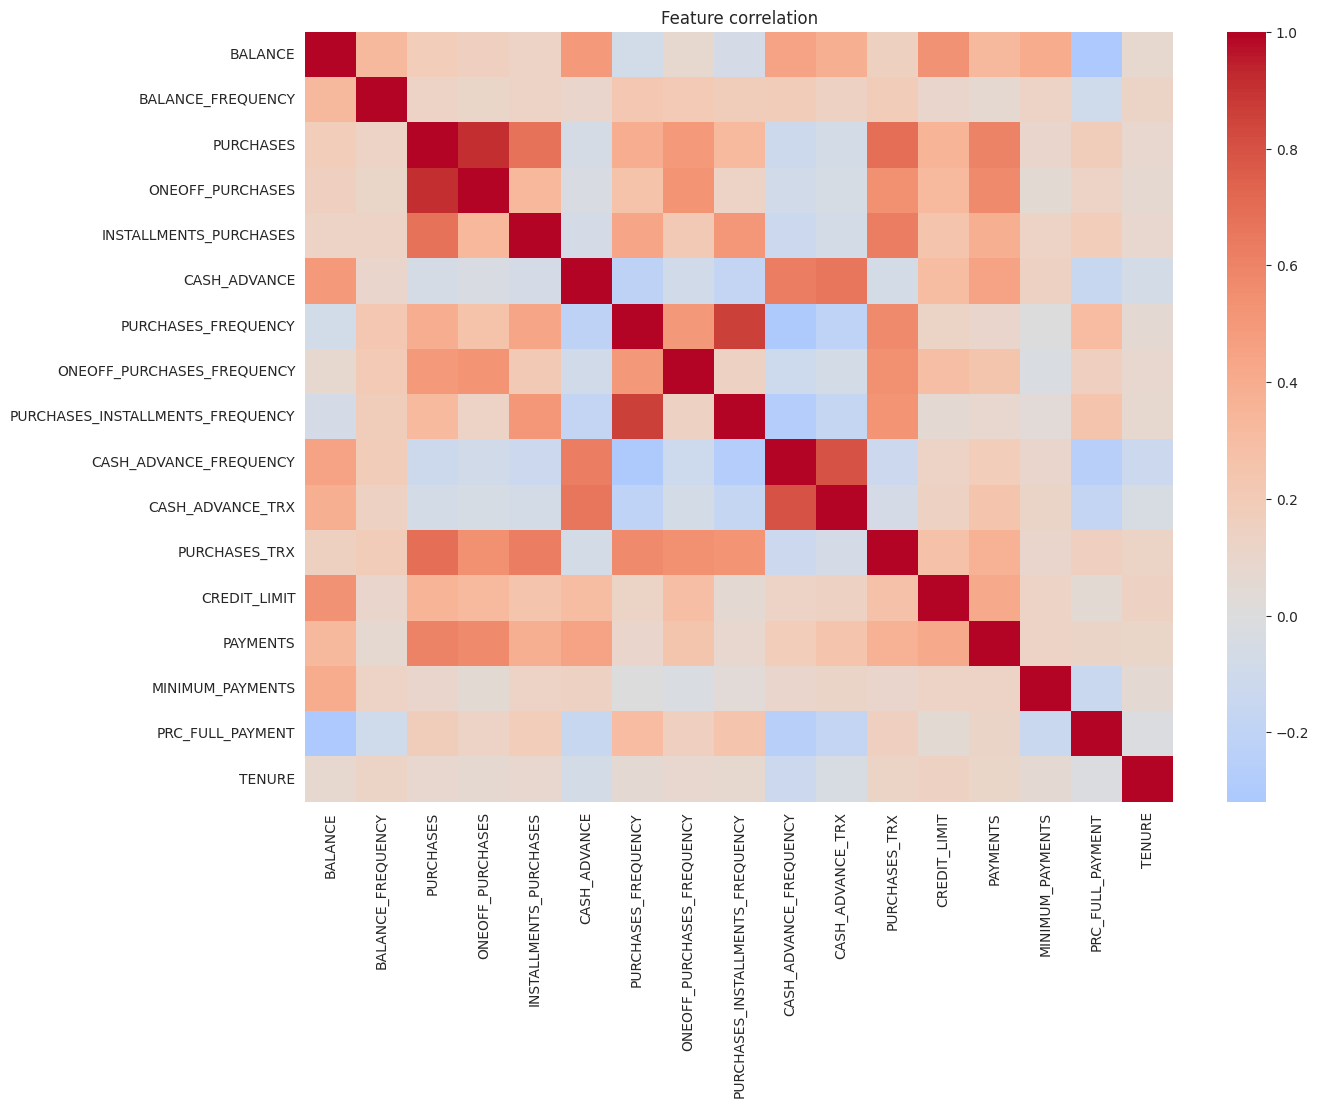

In [11]:

df_model = df.drop(columns=["CUST_ID"])

plt.figure(figsize=(14, 10))
sns.heatmap(df_model.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Feature correlation")
plt.show()


In [ ]:
df_model.hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()


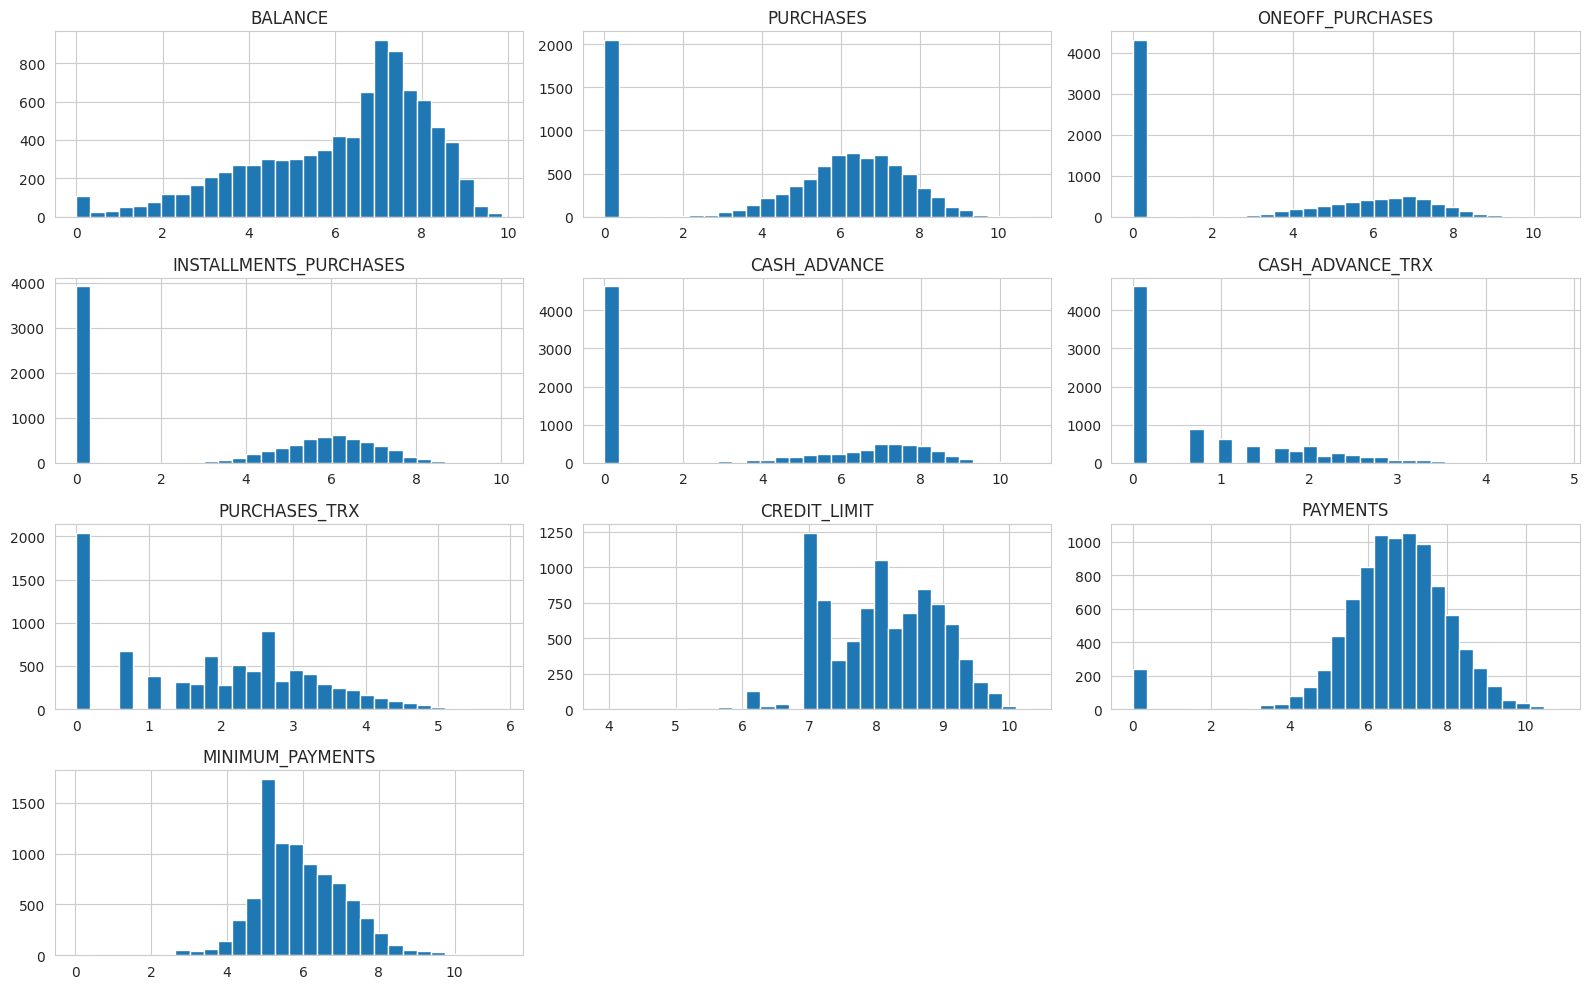

In [12]:
skewed_cols = [
    "BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE", "CASH_ADVANCE_TRX", "PURCHASES_TRX", "CREDIT_LIMIT",
    "PAYMENTS", "MINIMUM_PAYMENTS"
]

df_log = df_model.copy()
for col in skewed_cols:
    df_log[col] = np.log1p(df_log[col])

df_log[skewed_cols].hist(figsize=(16, 10), bins=30)
plt.tight_layout()
plt.show()


## 4. Scale features

In [13]:
feature_cols = df_log.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_log[feature_cols])
X_scaled.shape


(8950, 17)

In [15]:
pca_viz = PCA(n_components=2, random_state=42)
X_pca_viz = pca_viz.fit_transform(X_scaled)
print("Variance explained by 2 components:", pca_viz.explained_variance_ratio_.sum().round(3))


Variance explained by 2 components: 0.558


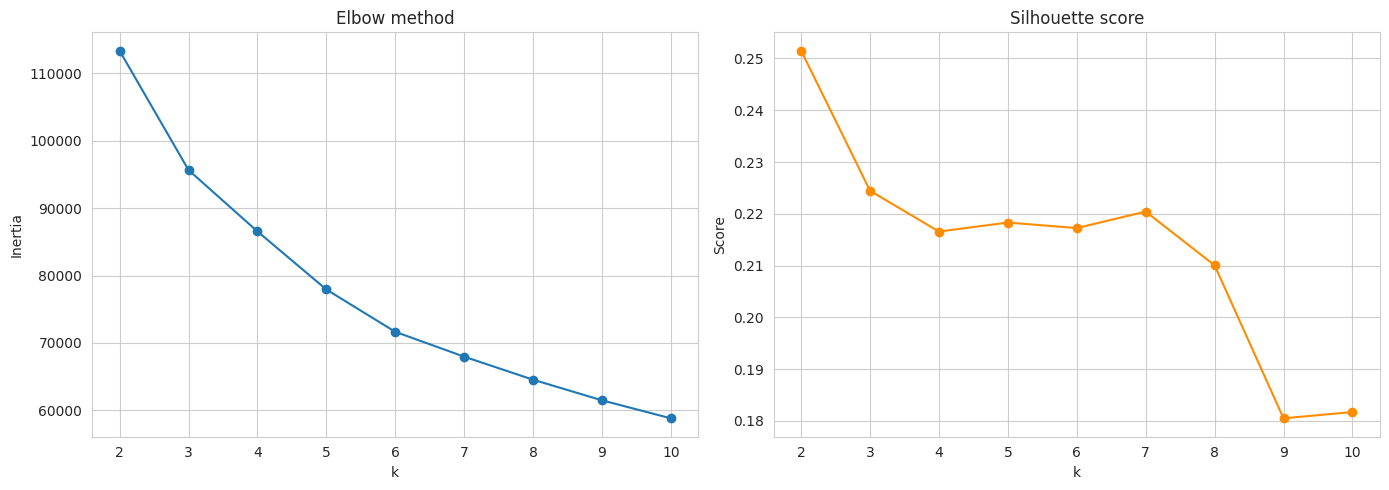

k=2: silhouette=0.251
k=3: silhouette=0.224
k=4: silhouette=0.217
k=5: silhouette=0.218
k=6: silhouette=0.217
k=7: silhouette=0.220
k=8: silhouette=0.210
k=9: silhouette=0.181
k=10: silhouette=0.182


In [14]:
inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(list(K_range), inertias, marker="o")
ax[0].set_title("Elbow method")
ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia")

ax[1].plot(list(K_range), sil_scores, marker="o", color="darkorange")
ax[1].set_title("Silhouette score")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

for k, s in zip(K_range, sil_scores):
    print(f"k={k}: silhouette={s:.3f}")


In [ ]:
K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df_model["CLUSTER"] = cluster_labels
print("Silhouette score:", silhouette_score(X_scaled, cluster_labels).round(3))
df_model["CLUSTER"].value_counts().sort_index()


In [ ]:
plot_df = pd.DataFrame(X_pca_viz, columns=["PC1", "PC2"])
plot_df["Cluster"] = cluster_labels.astype(str)

fig = px.scatter(
    plot_df, x="PC1", y="PC2", color="Cluster",
    title="Customer clusters (PCA projection)",
    opacity=0.6
)
fig.show()


In [ ]:
profile = df_model.groupby("CLUSTER")[feature_cols].mean().round(1)
profile


In [ ]:
key_features = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT",
                 "PAYMENTS", "PRC_FULL_PAYMENT", "TENURE"]

norm_profile = (profile[key_features] - profile[key_features].min()) / \
               (profile[key_features].max() - profile[key_features].min())

plt.figure(figsize=(10, 5))
sns.heatmap(norm_profile, annot=profile[key_features].values, fmt=".0f",
            cmap="YlGnBu", cbar=False)
plt.title("Cluster profile (color = relative rank, numbers = actual mean)")
plt.show()


In [ ]:
PERSONA_MAP = {
    0: "VIP / Premium Spender",
    1: "Low Spender",
    2: "Frequent / Loyal Spender",
    3: "High-Risk Revolver",
}

CAMPAIGN_MAP = {
    "VIP / Premium Spender": "Upgrade to premium card, raise credit limit, concierge perks",
    "Low Spender": "Cashback offers to increase card usage",
    "Frequent / Loyal Spender": "Airline miles & travel rewards program",
    "High-Risk Revolver": "Financial education content, credit counseling outreach",
}

df_model["PERSONA"] = df_model["CLUSTER"].map(PERSONA_MAP)
df_model["PERSONA"].value_counts()


## 8. Save the trained artifacts for the Streamlit app

In [ ]:
joblib.dump(scaler, "scaler.pkl")
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")
joblib.dump(skewed_cols, "skewed_cols.pkl")
joblib.dump(PERSONA_MAP, "persona_map.pkl")
joblib.dump(CAMPAIGN_MAP, "campaign_map.pkl")

print("Saved: scaler.pkl, kmeans_model.pkl, feature_cols.pkl, skewed_cols.pkl, persona_map.pkl, campaign_map.pkl")


In [16]:
from google.colab import files

for f in ["scaler.pkl", "kmeans_model.pkl", "feature_cols.pkl",
          "skewed_cols.pkl", "persona_map.pkl", "campaign_map.pkl"]:
    files.download(f)


FileNotFoundError: Cannot find file: scaler.pkl